In [1]:

import numpy as np
import matplotlib.pyplot as plt
from pypalettes import create_cmap
import matplotlib.patheffects as path_effects

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.edgecolor': 'white',

    # Text colors to black
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'ytick.color': 'black',
    'xtick.color': 'black',
    'legend.labelcolor': 'black',

    # Tick labels
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    # Axis spines, ticks, and edges to black
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.linewidth': 0.8,
})

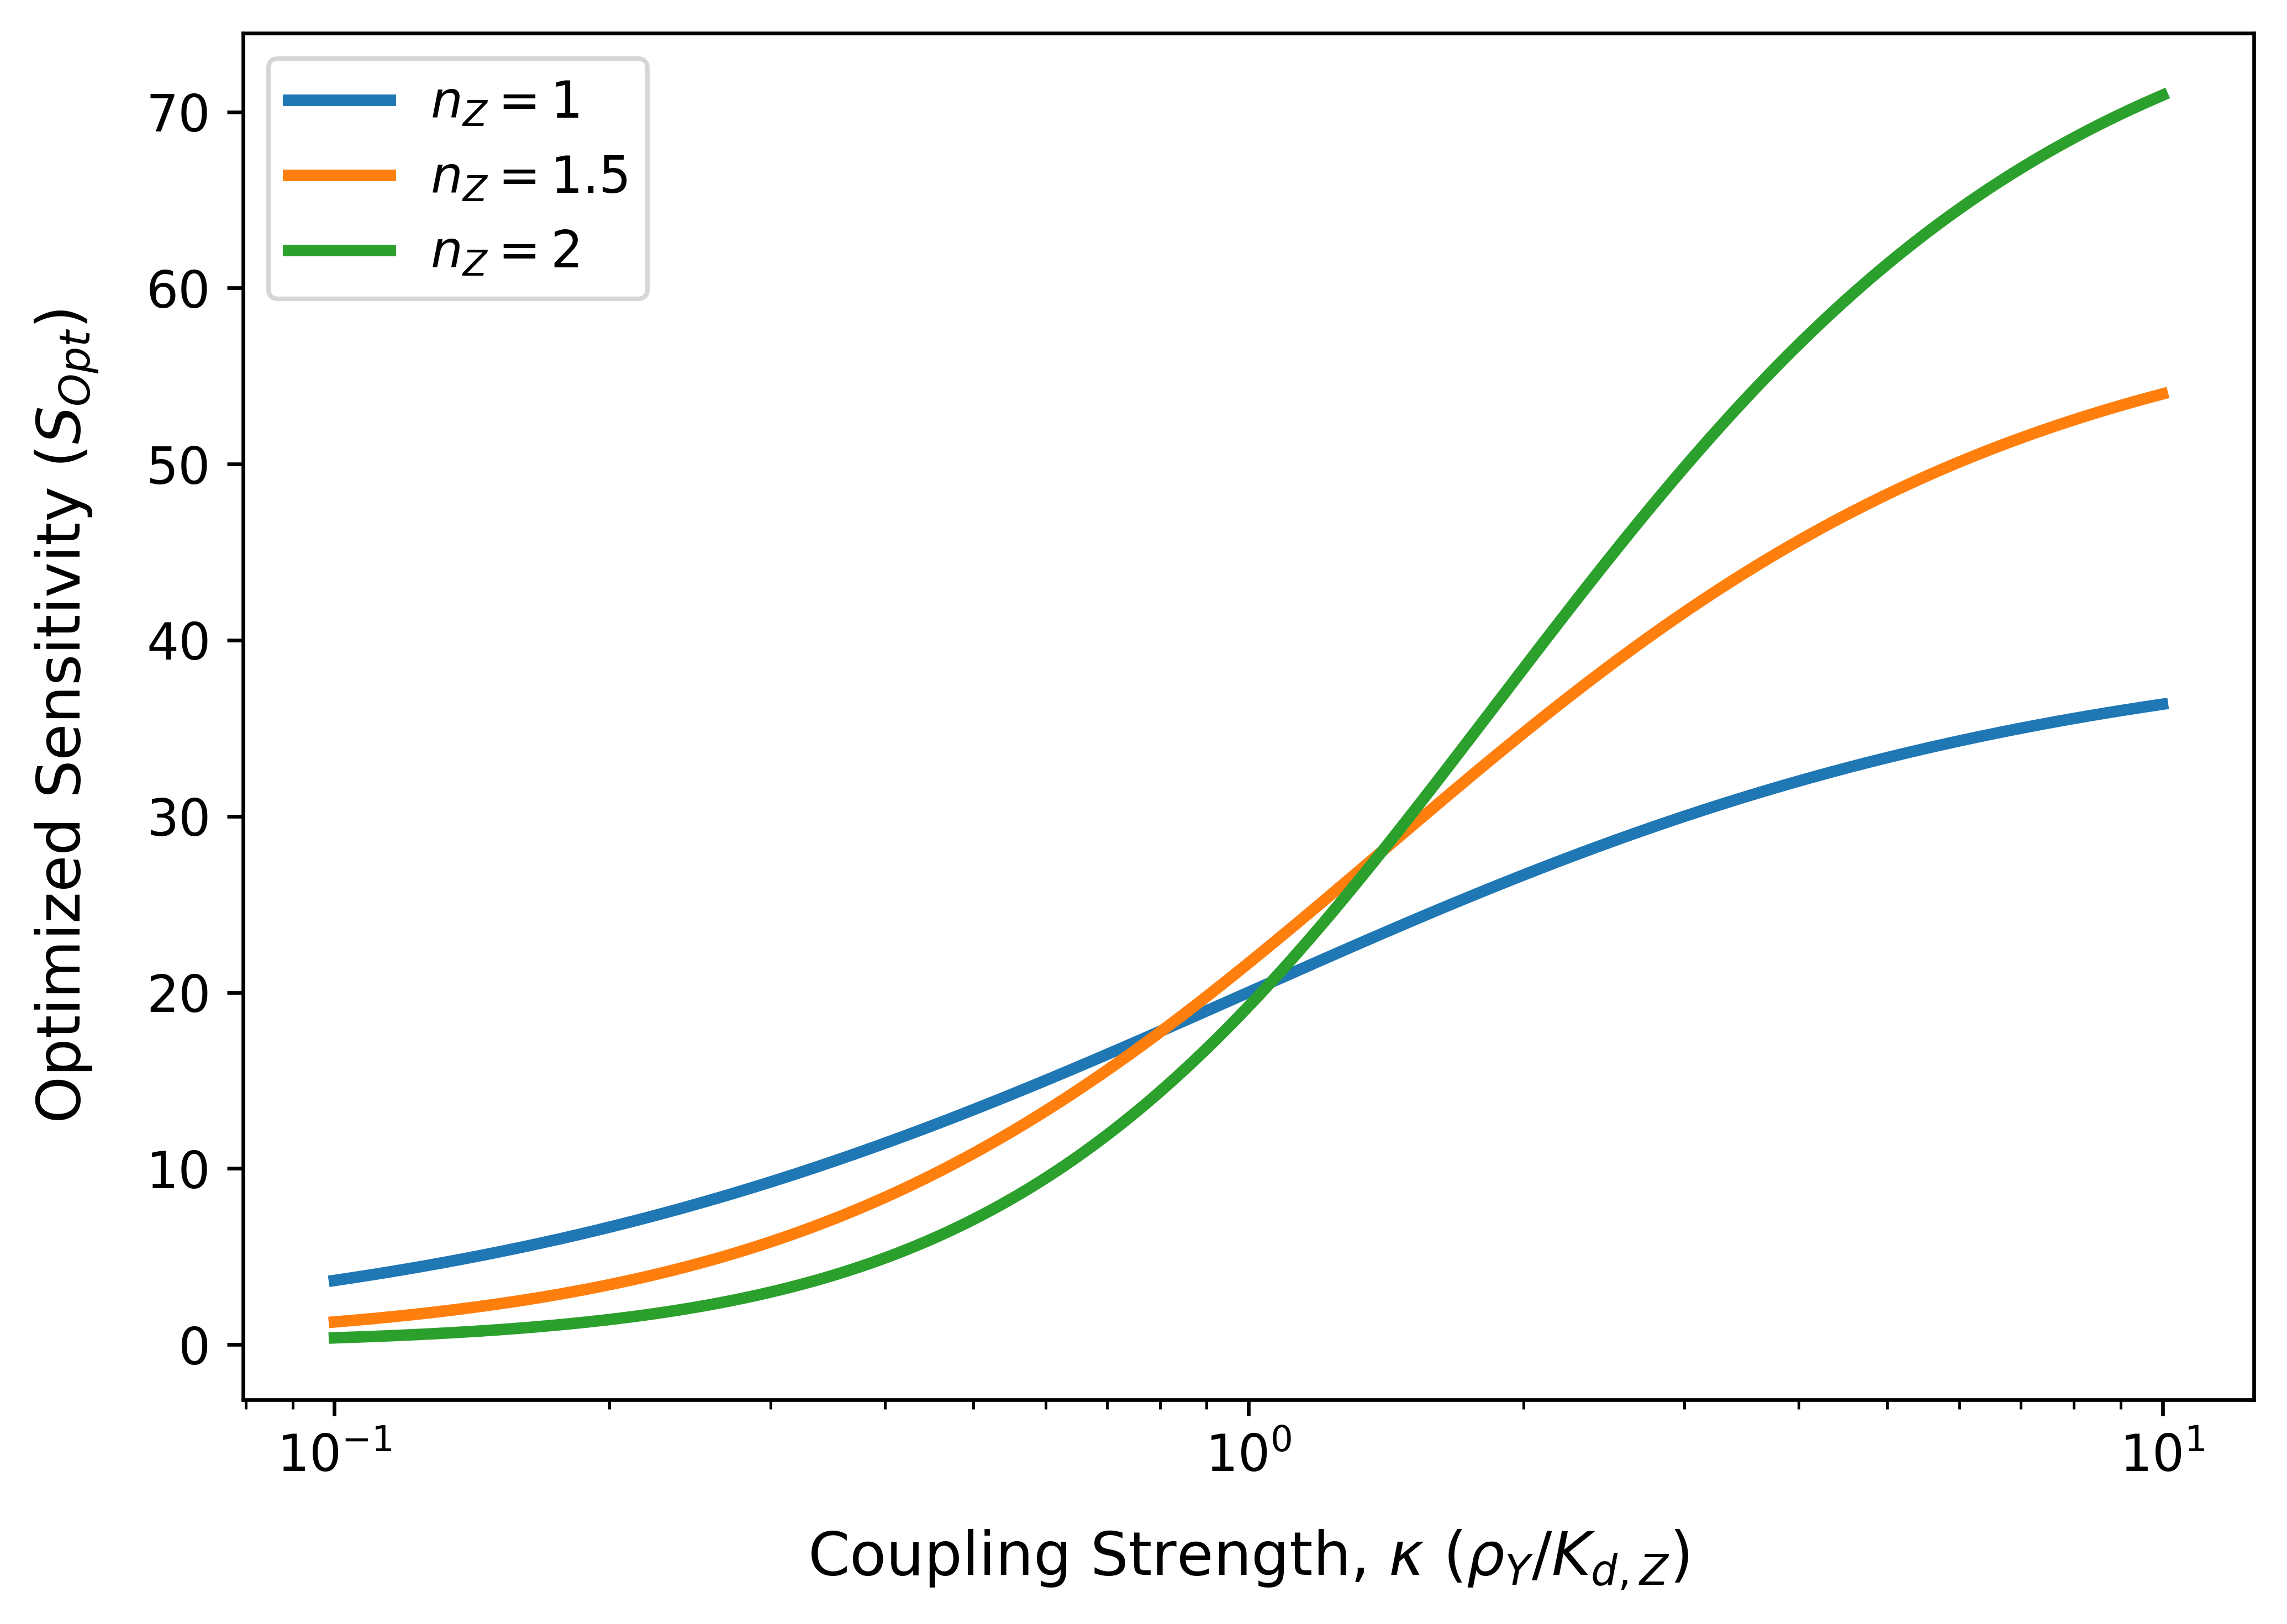

In [2]:

nY = 4.0
rhoZ = 40.0
kappa = np.logspace(-1, 1, 500)
nZ_values = [1, 1.5, 2]

def get_sensitivity(k, nY, nZ, rhoZ):
    #equation 13 main text
    f_term = (1 + k) / (2 + k)
    v1 = k / (1 + k)
    v2 = (2 + k) / (1 + k)
    num = (v2 * v1)**nZ
    den = (v1**nZ + v2**nZ)**2
    return nZ * nY * rhoZ * f_term * (num / den)

plt.figure(figsize=(7, 5), dpi=600)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for nZ, color in zip(nZ_values, colors):
    s_vals = get_sensitivity(kappa, nY, nZ, rhoZ)
    plt.plot(kappa, s_vals, label=f'$n_Z = {nZ}$', lw=2.5, color=color)


plt.xscale('log')
plt.xlabel(r'Coupling Strength, $\kappa$ ($\rho_Y / K_{d,Z}$)', fontsize=13, labelpad=10)
plt.ylabel(r'Optimized Sensitivity ($S_{Opt}$)', fontsize=13, labelpad=10)

plt.legend(frameon=True, fontsize=11, loc='upper left')
plt.tick_params(labelsize=11)
plt.tight_layout()

plt.show()

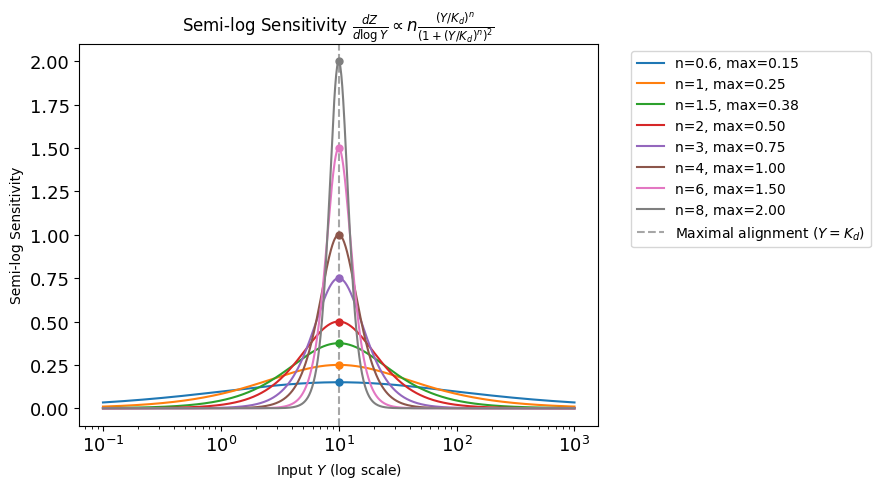

In [3]:

def semilog_sensitivity(y, n, kd):
    """Return the semi-log sensitivity dF/dlog(Y) = n * (Y/Kd)^n / (1 + (Y/Kd)^n)^2"""
    u = y / kd
    return n * (u ** n) / (1 + u ** n) ** 2

kd = 10
y = np.logspace(-1, 3, 1000)
n_values = [0.6, 1, 1.5, 2, 3, 4, 6, 8]

fig,ax=plt.subplots(figsize=(9, 5))

for n in n_values:
    f_y = semilog_sensitivity(y, n, kd)
    max_val = n / 4  # Theoretical maximum in semi-log space is always n/4
    line, = ax.plot(y, f_y, label=f"n={n}, max={max_val:.2f}")
    ax.plot(kd, max_val, marker='o', color=line.get_color(), markersize=5)

ax.axvline(x=kd, color='gray', linestyle='--', alpha=0.7, zorder=0, label=f"Maximal alignment ($Y=K_d$)")

ax.set_xscale('log')
ax.set_title("Semi-log Sensitivity $\\frac{dZ}{d\\log Y} \\propto n \\frac{(Y/K_d)^n}{(1 + (Y/K_d)^n)^2}$")
ax.set_xlabel("Input $Y$ (log scale)")
ax.set_ylabel("Semi-log Sensitivity")
ax.tick_params(axis='both', labelsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.tight_layout()
plt.savefig("simpleregulation_semilog_amplification.png", dpi=600)
plt.show()

In [4]:
def solve_Ufree(Ut, S_U, Kb_U):
    """Exact closed-form solution for U_free from U_tot mass balance."""
    Ut = np.asarray(Ut, dtype=float)
    D = (S_U + Kb_U - Ut)**2 + 4.0 * Ut * Kb_U
    return 0.5 * (Ut - S_U - Kb_U + np.sqrt(D))

def get_Kd_ea(Uf, Kd, S_U, Kb_U):
    """State-dependent effective Kd: K_d,ea = K_d * (1 + σ(U_free))"""
    # sigma = S_U * Uf / (Kb_U + Uf)
    sigma = S_U * Kd / (Kb_U + Kd)
    return Kd * (1.0 + sigma)

def phi_log(Uf, S_U, Kb_U):
    """Logarithmic shunt elasticity: dlog(U_free)/dlog(U_tot)"""
    num = 1.0 + S_U / (Kb_U + Uf)
    den = 1.0 + (S_U * Kb_U) / (Kb_U + Uf)**2
    return num / den

def semilog_sensitivity_total(Ut, n, Kd, rho, beta, S_U, Kb_U):
    """
    Total semi-log sensitivity: |dZ / dlog(U_tot)|
    Calculated elegantly via: (dZ / dlog(U_free)) * Phi_log
    """
    Uf = solve_Ufree(Ut, S_U, Kb_U)
    Kd_ea = get_Kd_ea(Uf, Kd, S_U, Kb_U)
    s = Uf / Kd_ea
    dZ_dlogUf = rho * (1.0 - beta) * n * (s**n) / (1.0 + s**n)**2
    return dZ_dlogUf * phi_log(Uf, S_U, Kb_U)

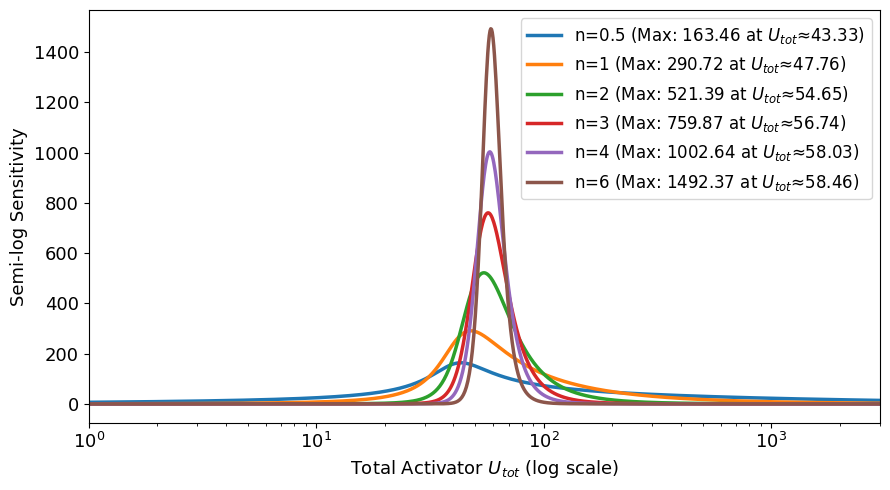

In [5]:
# System parameters
Kd = 1.0          # Intrinsic dissociation constant
rho = 400.0       # Maximum expression level , depends on production rate, degradation rate and copy number
beta = 0.05       # Basal expression fraction
S_U = 40.0        # Total shunt binding sites (s_U * C_U)
Kb_U = 1        # Basal Kd for shunt binding
n_values = [0.5, 1, 2, 3, 4, 6]
Ut = np.logspace(-3, 3.5, 2000)

fig,ax=plt.subplots(figsize=(9, 5))

for n in n_values:
    sens = semilog_sensitivity_total(Ut, n, Kd, rho, beta, S_U, Kb_U)
    max_sens = np.max(sens)
    Ut_star = Ut[np.argmax(sens)]
    ax.plot(Ut, sens, linewidth=2.5,
             label=f"n={n} (Max: {max_sens:.2f} at $U_{{tot}}$≈{Ut_star:.2f})")

ax.set_xscale('log')
# ax.set_title("Semi-log Sensitivity with State-Dependent Shunt \n $|dZ / d\\log U_{tot}|$")
ax.set_xlabel("Total Activator $U_{tot}$ (log scale)", fontsize=13)
ax.set_ylabel("Semi-log Sensitivity", fontsize=13)
ax.set_xlim(1e0, 3e3)
ax.tick_params(axis='both', labelsize=13)
plt.grid(False)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("eq14.png", dpi=600)
plt.show()

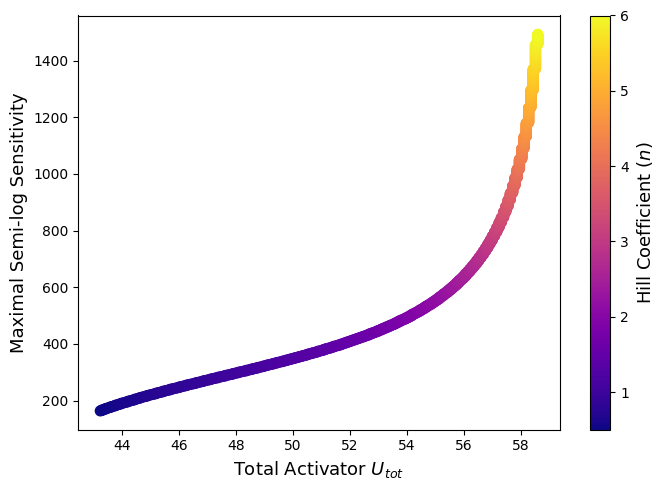

In [6]:
n_continuous = np.linspace(0.5, 6.0, 1000)
max_sensitivities = []
optimal_Ut = []
Ut_array = np.logspace(0, 3, 5000)
for n in n_continuous:
    sens = semilog_sensitivity_total(Ut_array, n, Kd, rho, beta, S_U, Kb_U)
    max_sensitivities.append(np.max(sens))
    optimal_Ut.append(Ut_array[np.argmax(sens)])

fig,ax=plt.subplots(figsize=(7, 5))

sc = ax.scatter(optimal_Ut, max_sensitivities, c=n_continuous, cmap='plasma', s=50, zorder=3)
ax.plot(optimal_Ut, max_sensitivities, color='white', alpha=0.5, lw=2, zorder=2)

# ax.set_xscale('log')
ax.set_xlabel("Total Activator $U_{tot}$ ", fontsize=13)
ax.set_ylabel("Maximal Semi-log Sensitivity", fontsize=13)
cbar = plt.colorbar(sc)
cbar.set_label("Hill Coefficient ($n$)", fontsize=13)
plt.tight_layout()
plt.savefig("eq14_peaks.png", dpi=600)
plt.show()


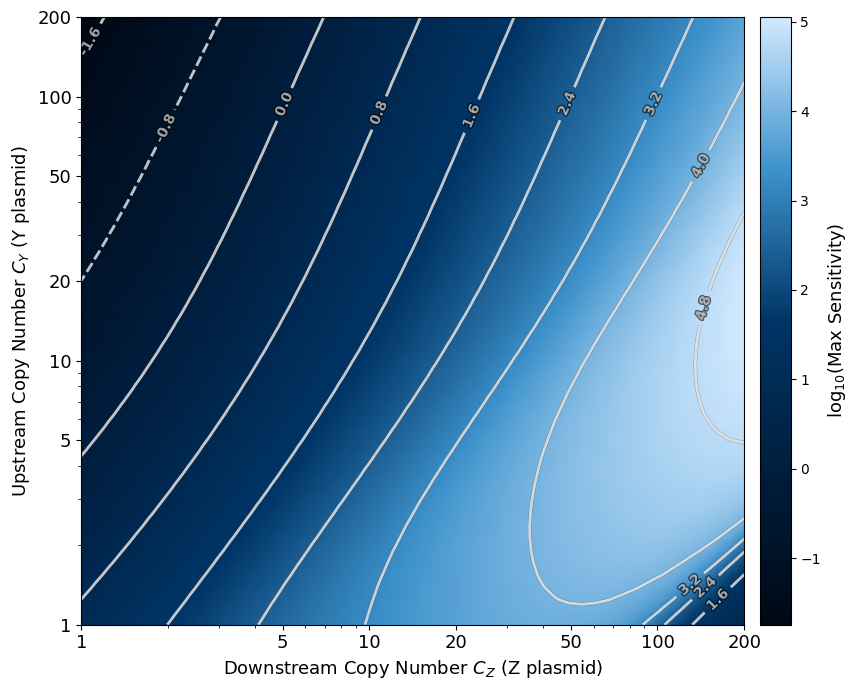

In [7]:
def cascade_semilog_sensitivity(X_tot, C_Y, C_Z):
    """
    Computes the total semi-log cascade sensitivity |dZ / dlog X_tot|
    using the elegant log-domain chain rule.
    """
    Kd_Y, Kd_Z = 1.0, 1.0
    alpha_Y, alpha_Z = 100.0, 100.0
    tau_Y, tau_Z = 2.0, 2.0
    n_Y, n_Z = 1.5, 1.5
    beta_Y, beta_Z = 0.05, 0.05
    Kb_X, Kb_Y = 1, 1 #same as Kd
    s_per_copy = 1.0
    rho_Y = alpha_Y * tau_Y * C_Y
    rho_Z = alpha_Z * tau_Z * C_Z
    S_X = s_per_copy * C_Y  # Decoy sites for X scale with Y's plasmid
    S_Y = 2*s_per_copy * C_Z  # Decoy sites for Y scale with Z's plasmid doubled for pTeto's promoter

    # --- STAGE 1: X -> Y ---
    X_free = solve_Ufree(X_tot, S_X, Kb_X)
    Phi_log_X = phi_log(X_free, S_X, Kb_X)
    Kd_ea_Y = get_Kd_ea(X_free, Kd_Y, S_X, Kb_X)

    s_X = X_free / Kd_ea_Y
    # dY_tot / dlog(X_free)
    dYtot_dlogXfree = rho_Y * (1.0 - beta_Y) * n_Y * (s_X**n_Y) / (1.0 + s_X**n_Y)**2
    # Absolute Y_tot
    Y_tot = rho_Y * (beta_Y + (1.0 - beta_Y) * (s_X**n_Y) / (1.0 + s_X**n_Y))

    # --- STAGE 2: Y -> Z ---
    Y_free = solve_Ufree(Y_tot, S_Y, Kb_Y)
    Phi_log_Y = phi_log(Y_free, S_Y, Kb_Y)
    Kd_ea_Z = get_Kd_ea(Y_free, Kd_Z, S_Y, Kb_Y)

    s_Y = Y_free / Kd_ea_Z
    # dZ / dlog(Y_free)
    dZ_dlogYfree = rho_Z * (1.0 - beta_Z) * n_Z * (s_Y**n_Z) / (1.0 + s_Y**n_Z)**2

    # --- TOTAL CHAIN RULE IN LOG SPACE ---
    # |dZ/dlogX_tot| = (dZ/dlogYfree) * Phi_log_Y * (1/Y_tot) * (dYtot/dlogXfree) * Phi_log_X
    return dZ_dlogYfree * Phi_log_Y * (1.0 / Y_tot) * dYtot_dlogXfree * Phi_log_X
# copy_grid = [1, 5, 10, 20, 50, 100, 200]
num_points = 50
C_Y_vals = np.logspace(np.log10(1), np.log10(200), num_points)
C_Z_vals = np.logspace(np.log10(1), np.log10(200), num_points)
X_vals = np.logspace(-2, 3, 2000) # Input range to search for the maximum peak
# gain_matrix = np.zeros((len(copy_grid), len(copy_grid)))
gain_matrix = np.zeros((num_points, num_points))
for i, C_Y in enumerate(C_Y_vals):
    for j, C_Z in enumerate(C_Z_vals):
        sensitivities = cascade_semilog_sensitivity(X_vals, C_Y, C_Z)
        gain_matrix[i, j] = np.max(sensitivities)

fig, ax = plt.subplots(figsize=(9, 7))
ice_blue = ["#000814", "#001D3D", "#003566", "#3E92CC", "#D1E9FF"]
cmap_main = create_cmap(colors=ice_blue, cmap_type="continuous")
CZ_mesh, CY_mesh = np.meshgrid(C_Z_vals, C_Y_vals)
im = ax.pcolormesh(CZ_mesh, CY_mesh, np.log10(gain_matrix),
                   cmap=cmap_main, shading='gouraud')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Downstream Copy Number $C_Z$ (Z plasmid)', fontsize=13)
ax.set_ylabel('Upstream Copy Number $C_Y$ (Y plasmid)', fontsize=13)
# ax.set_title('Maximum Cascade Semi-log Sensitivity\n$|dZ/d\\log X_{tot}|$ (log$_{10}$ scale)', fontsize=14)
ticks = [1, 5, 10, 20, 50, 100, 200]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('log$_{10}$(Max Sensitivity)', fontsize=13)

CS=ax.contour(CZ_mesh, CY_mesh, np.log10(gain_matrix), colors='white', linewidths=2.0, alpha=0.5,levels=10)
plt.setp(CS.collections, path_effects=[
    path_effects.withStroke(linewidth=2.5, foreground='#000000', alpha=0.4),
    path_effects.Normal()
])
clbls = ax.clabel(CS, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls,fontweight='bold', path_effects=[
    path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)
])
plt.tick_params(axis='both', labelsize=13)
plt.tight_layout()
plt.show()

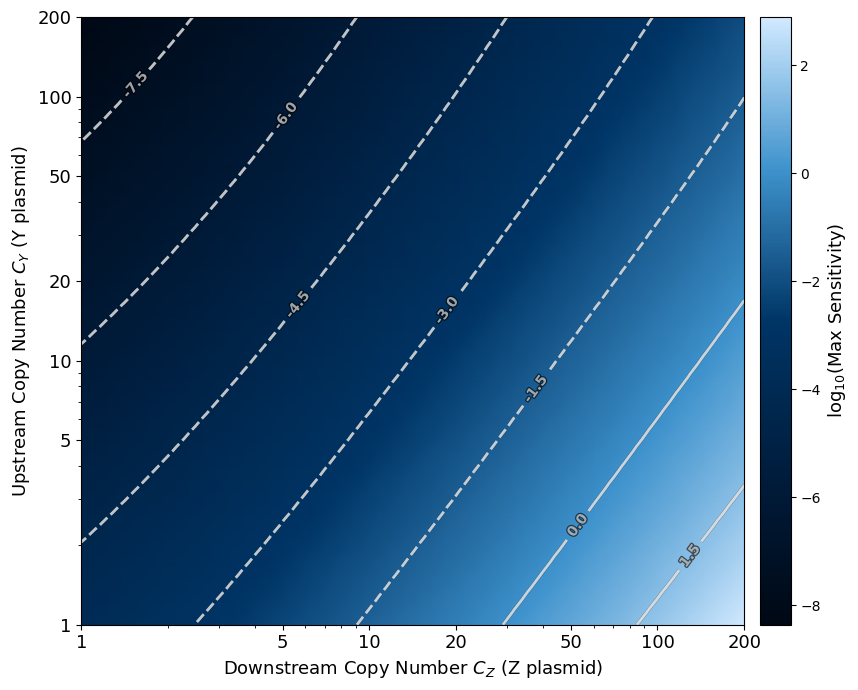

In [8]:
def cascade_semilog_sensitivity(X_tot, C_Y, C_Z):
    """
    Computes the total semi-log cascade sensitivity |dZ / dlog X_tot|
    using the elegant log-domain chain rule.
    """
    Kd_Y, Kd_Z = 100.0, 1.0
    alpha_Y, alpha_Z = 100.0, 100.0
    tau_Y, tau_Z = 60.0, 2.0
    n_Y, n_Z = 0.5, 2
    beta_Y, beta_Z = 0.15, 0.01
    Kb_X, Kb_Y = 100.0, 1.0
    s_per_copy = 1.0
    rho_Y = alpha_Y * tau_Y * C_Y
    rho_Z = alpha_Z * tau_Z * C_Z
    S_X = s_per_copy * C_Y  # Decoy sites for X scale with Y's plasmid
    S_Y = 2*s_per_copy * C_Z  # Decoy sites for Y scale with Z's plasmid, but with a stronger effect (2x) as pTeto does

    # X -> Y
    X_free = solve_Ufree(X_tot, S_X, Kb_X)
    Phi_log_X = phi_log(X_free, S_X, Kb_X)
    Kd_ea_Y = get_Kd_ea(X_free, Kd_Y, S_X, Kb_X)

    s_X = X_free / Kd_ea_Y
    # dY_tot / dlog(X_free)
    dYtot_dlogXfree = rho_Y * (1.0 - beta_Y) * n_Y * (s_X**n_Y) / (1.0 + s_X**n_Y)**2
    # Absolute Y_tot
    Y_tot = rho_Y * (beta_Y + (1.0 - beta_Y) * (s_X**n_Y) / (1.0 + s_X**n_Y))

    #  Y -> Z
    Y_free = solve_Ufree(Y_tot, S_Y, Kb_Y)
    Phi_log_Y = phi_log(Y_free, S_Y, Kb_Y)
    Kd_ea_Z = get_Kd_ea(Y_free, Kd_Z, S_Y, Kb_Y)

    s_Y = Y_free / Kd_ea_Z
    # dZ / dlog(Y_free)
    dZ_dlogYfree = rho_Z * (1.0 - beta_Z) * n_Z * (s_Y**n_Z) / (1.0 + s_Y**n_Z)**2

    # |dZ/dlogX_tot| = (dZ/dlogYfree) * Phi_log_Y * (1/Y_tot) * (dYtot/dlogXfree) * Phi_log_X
    return dZ_dlogYfree * Phi_log_Y * (1.0 / Y_tot) * dYtot_dlogXfree * Phi_log_X
# copy_grid = [1, 5, 10, 20, 50, 100, 200]
num_points = 50
C_Y_vals = np.logspace(np.log10(1), np.log10(200), num_points)
C_Z_vals = np.logspace(np.log10(1), np.log10(200), num_points)
X_vals = np.logspace(-2, 3, 2000)
# gain_matrix = np.zeros((len(copy_grid), len(copy_grid)))
gain_matrix = np.zeros((num_points, num_points))
for i, C_Y in enumerate(C_Y_vals):
    for j, C_Z in enumerate(C_Z_vals):
        sensitivities = cascade_semilog_sensitivity(X_vals, C_Y, C_Z)
        gain_matrix[i, j] = np.max(sensitivities)

fig, ax = plt.subplots(figsize=(9, 7))
ice_blue = ["#000814", "#001D3D", "#003566", "#3E92CC", "#D1E9FF"]
cmap_main = create_cmap(colors=ice_blue, cmap_type="continuous")
CZ_mesh, CY_mesh = np.meshgrid(C_Z_vals, C_Y_vals)
im = ax.pcolormesh(CZ_mesh, CY_mesh, np.log10(gain_matrix),
                   cmap=cmap_main, shading='gouraud')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Downstream Copy Number $C_Z$ (Z plasmid)', fontsize=13)
ax.set_ylabel('Upstream Copy Number $C_Y$ (Y plasmid)', fontsize=13)
# ax.set_title('Maximum Cascade Semi-log Sensitivity\n$|dZ/d\\log X_{tot}|$ (log$_{10}$ scale)', fontsize=14)
ticks = [1, 5, 10, 20, 50, 100, 200]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('log$_{10}$(Max Sensitivity)', fontsize=13)

CS=ax.contour(CZ_mesh, CY_mesh, np.log10(gain_matrix), colors='white', linewidths=2.0, alpha=0.5,levels=10)
plt.setp(CS.collections, path_effects=[
    path_effects.withStroke(linewidth=2.5, foreground='#000000', alpha=0.4),
    path_effects.Normal()
])
clbls = ax.clabel(CS, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls,fontweight='bold', path_effects=[
    path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)
])
plt.tick_params(axis='both', labelsize=13)
plt.tight_layout()
plt.show()

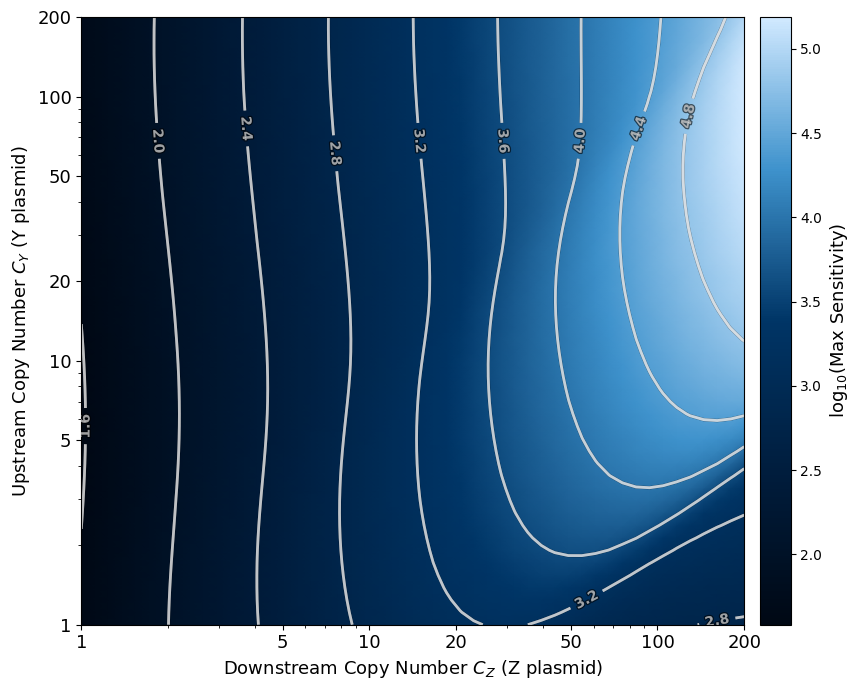

In [12]:
def cascade_semilog_sensitivity(X_tot, C_Y, C_Z):
    """
    Computes the total semi-log cascade sensitivity |dZ / dlog X_tot|
    using the elegant log-domain chain rule.
    """
    Kd_Y, Kd_Z = 1.0, 2.0
    alpha_Y, alpha_Z = 100.0, 100.0
    tau_Y, tau_Z = 1.0, 2.0
    n_Y, n_Z = 2, 0.5
    beta_Y, beta_Z = 0.015, 0.15
    Kb_X, Kb_Y = 1.0,2.0
    s_per_copy = 1.0
    rho_Y = alpha_Y * tau_Y * C_Y
    rho_Z = alpha_Z * tau_Z * C_Z
    S_X = s_per_copy * C_Y  # Decoy sites for X scale with Y's plasmid
    S_Y = 2*s_per_copy * C_Z  # Decoy sites for Y scale with Z's plasmid, but with a stronger effect (2x) as pTeto does

    # X -> Y
    X_free = solve_Ufree(X_tot, S_X, Kb_X)
    Phi_log_X = phi_log(X_free, S_X, Kb_X)
    Kd_ea_Y = get_Kd_ea(X_free, Kd_Y, S_X, Kb_X)

    s_X = X_free / Kd_ea_Y
    # dY_tot / dlog(X_free)
    dYtot_dlogXfree = rho_Y * (1.0 - beta_Y) * n_Y * (s_X**n_Y) / (1.0 + s_X**n_Y)**2
    # Absolute Y_tot
    Y_tot = rho_Y * (beta_Y + (1.0 - beta_Y) * (s_X**n_Y) / (1.0 + s_X**n_Y))

    #  Y -> Z
    Y_free = solve_Ufree(Y_tot, S_Y, Kb_Y)
    Phi_log_Y = phi_log(Y_free, S_Y, Kb_Y)
    Kd_ea_Z = get_Kd_ea(Y_free, Kd_Z, S_Y, Kb_Y)

    s_Y = Y_free / Kd_ea_Z
    # dZ / dlog(Y_free)
    dZ_dlogYfree = rho_Z * (1.0 - beta_Z) * n_Z * (s_Y**n_Z) / (1.0 + s_Y**n_Z)**2

    # |dZ/dlogX_tot| = (dZ/dlogYfree) * Phi_log_Y * (1/Y_tot) * (dYtot/dlogXfree) * Phi_log_X
    return dZ_dlogYfree * Phi_log_Y * (1.0 / Y_tot) * dYtot_dlogXfree * Phi_log_X
# copy_grid = [1, 5, 10, 20, 50, 100, 200]
num_points = 50
C_Y_vals = np.logspace(np.log10(1), np.log10(200), num_points)
C_Z_vals = np.logspace(np.log10(1), np.log10(200), num_points)
X_vals = np.logspace(-2, 3, 2000)
# gain_matrix = np.zeros((len(copy_grid), len(copy_grid)))
gain_matrix = np.zeros((num_points, num_points))
for i, C_Y in enumerate(C_Y_vals):
    for j, C_Z in enumerate(C_Z_vals):
        sensitivities = cascade_semilog_sensitivity(X_vals, C_Y, C_Z)
        gain_matrix[i, j] = np.max(sensitivities)

fig, ax = plt.subplots(figsize=(9, 7))
ice_blue = ["#000814", "#001D3D", "#003566", "#3E92CC", "#D1E9FF"]
cmap_main = create_cmap(colors=ice_blue, cmap_type="continuous")
CZ_mesh, CY_mesh = np.meshgrid(C_Z_vals, C_Y_vals)
im = ax.pcolormesh(CZ_mesh, CY_mesh, np.log10(gain_matrix),
                   cmap=cmap_main, shading='gouraud')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Downstream Copy Number $C_Z$ (Z plasmid)', fontsize=13)
ax.set_ylabel('Upstream Copy Number $C_Y$ (Y plasmid)', fontsize=13)
# ax.set_title('Maximum Cascade Semi-log Sensitivity\n$|dZ/d\\log X_{tot}|$ (log$_{10}$ scale)', fontsize=14)
ticks = [1, 5, 10, 20, 50, 100, 200]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('log$_{10}$(Max Sensitivity)', fontsize=13)

CS=ax.contour(CZ_mesh, CY_mesh, np.log10(gain_matrix), colors='white', linewidths=2.0, alpha=0.5,levels=10)
plt.setp(CS.collections, path_effects=[
    path_effects.withStroke(linewidth=2.5, foreground='#000000', alpha=0.4),
    path_effects.Normal()
])
clbls = ax.clabel(CS, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls,fontweight='bold', path_effects=[
    path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)
])
plt.tick_params(axis='both', labelsize=13)
plt.tight_layout()
plt.show()